# Training curves

Parse `training.csv` (stdout log from `train.py`) and plot train vs validation latent MSE by epoch.

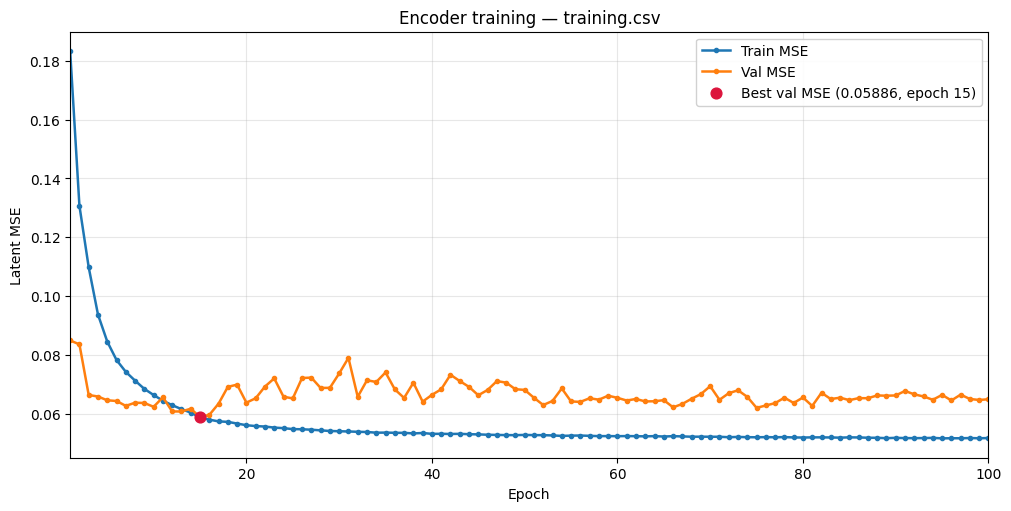

Parsed 100 epochs | final train MSE=0.05171 | final val MSE=0.06490 | best val MSE=0.05886 @ epoch 15


In [1]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

LOG_PATH = Path("training.csv")
EPOCH_RE = re.compile(
    r"Epoch\s+(\d+)/\d+\s+\|\s+train\s+[\d.]+\s+\(mse=([\d.]+)\)\s+\|\s+val\s+[\d.]+\s+\(mse=([\d.]+)\)"
)


def load_training_log(path: Path) -> pd.DataFrame:
    rows: list[dict[str, float | int]] = []
    for line in path.read_text(encoding="utf-8").splitlines():
        m = EPOCH_RE.search(line)
        if not m:
            continue
        rows.append(
            {
                "epoch": int(m.group(1)),
                "train_mse": float(m.group(2)),
                "val_mse": float(m.group(3)),
            }
        )
    if not rows:
        raise ValueError(f"No epoch lines parsed from {path.resolve()}")
    return pd.DataFrame(rows).sort_values("epoch").reset_index(drop=True)


df = load_training_log(LOG_PATH)
best_idx = df["val_mse"].idxmin()
best = df.loc[best_idx]

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
ax.plot(df["epoch"], df["train_mse"], marker="o", markersize=3, lw=1.8, label="Train MSE")
ax.plot(df["epoch"], df["val_mse"], marker="o", markersize=3, lw=1.8, label="Val MSE")
ax.scatter(
    [best["epoch"]],
    [best["val_mse"]],
    s=60,
    color="crimson",
    zorder=3,
    label=f"Best val MSE ({best['val_mse']:.5f}, epoch {int(best['epoch'])})",
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Latent MSE")
ax.set_title(f"Encoder training — {LOG_PATH.name}")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", framealpha=0.9)
ax.set_xlim(df["epoch"].min(), df["epoch"].max())

plt.show()

print(
    f"Parsed {len(df)} epochs | "
    f"final train MSE={df['train_mse'].iloc[-1]:.5f} | "
    f"final val MSE={df['val_mse'].iloc[-1]:.5f} | "
    f"best val MSE={best['val_mse']:.5f} @ epoch {int(best['epoch'])}"
)